In [1]:
REPO = '../'
RESULT_TABLE = f'{REPO}/data/table'
RESULT_OBJ = f'{REPO}/data/object'
FIGURE_FOLDER= f'{REPO}/data/figure'
SETTING_FOLDER = f'{REPO}/data/setting'
EXTERNAL_DATA=f'{REPO}/data/external'
# load Terra API for get data table from Terra
import sys
sys.path.append(REPO)
from settings import COLOR_PAlETTE
from utils.visual import *

import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scPipe as sp
import scanpy as sc
import seaborn as sns
import warnings
import commentjson
import patchworklib as pw
### Additional Colormap
with open(f'{SETTING_FOLDER}/ColorMap.json','r') as f:
    colormap = commentjson.load(f)
COLOR_PAlETTE.update(colormap)
plt.style.use(f'{REPO}/paper.mplstyle')
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2
%matplotlib inline

cannot import name 'Strips' from 'plotnine.facets.strips' (/home/analysis/miniconda3/envs/scPipe/lib/python3.8/site-packages/plotnine/facets/strips.py)


<Figure size 72x72 with 0 Axes>

In [2]:
def overlap(c1,c2):
    c1 = set(c1)
    c2 = set(c2)
    return len(c1.intersection(c2))

In [3]:
split1 = pd.read_csv(f'{RESULT_TABLE}/MPs/Tumor_Split_1/MP_Programs.gmt',sep='\t',header=None,index_col=0).iloc[:,1:].T
split2 = pd.read_csv(f'{RESULT_TABLE}/MPs/Tumor_Split_2/MP_Programs.gmt',sep='\t',header=None,index_col=0).iloc[:,1:].T
splits = pd.read_csv( f'{RESULT_TABLE}/MPs/SPLIT_MP_Programs.gmt',sep='\t',header=None,index_col=0).iloc[:,1:].T
tumor = pd.read_csv(f'{RESULT_TABLE}/MPs/Tumor/MP_Programs.gmt',sep='\t',header=None,index_col=0).iloc[:,1:].T
# TODO: Replace the random
random_result = []
for i in range(10):
    random = pd.read_csv( f'{RESULT_TABLE}/MPs/TumorRandom95_{i}/MP_Programs.gmt',sep='\t',header=None,index_col=0).iloc[:,1:].T
    sm = random.apply(
        lambda c1:
           tumor.apply(
            lambda c2: overlap(c1,c2)
            ,axis=0)
        ,axis=0).max(axis=1).sort_values() /50
    sm.name = f'TumorRandom90_{i}'

    random_result.append(sm)
random_result=pd.DataFrame(random_result)
random_result.index.name = 'random'
random_result.columns.name ='MPs'

In [4]:

sm1 = split1.apply(
        lambda c1:
           tumor.apply(
            lambda c2: overlap(c1,c2)
            ,axis=0)
        ,axis=0)
sm2 = split2.apply(
        lambda c1:
           tumor.apply(
            lambda c2: overlap(c1,c2)
            ,axis=0)
        ,axis=0)
sm3 = splits.apply(
        lambda c1:
           tumor.apply(
            lambda c2: overlap(c1,c2)
            ,axis=0)
        ,axis=0)


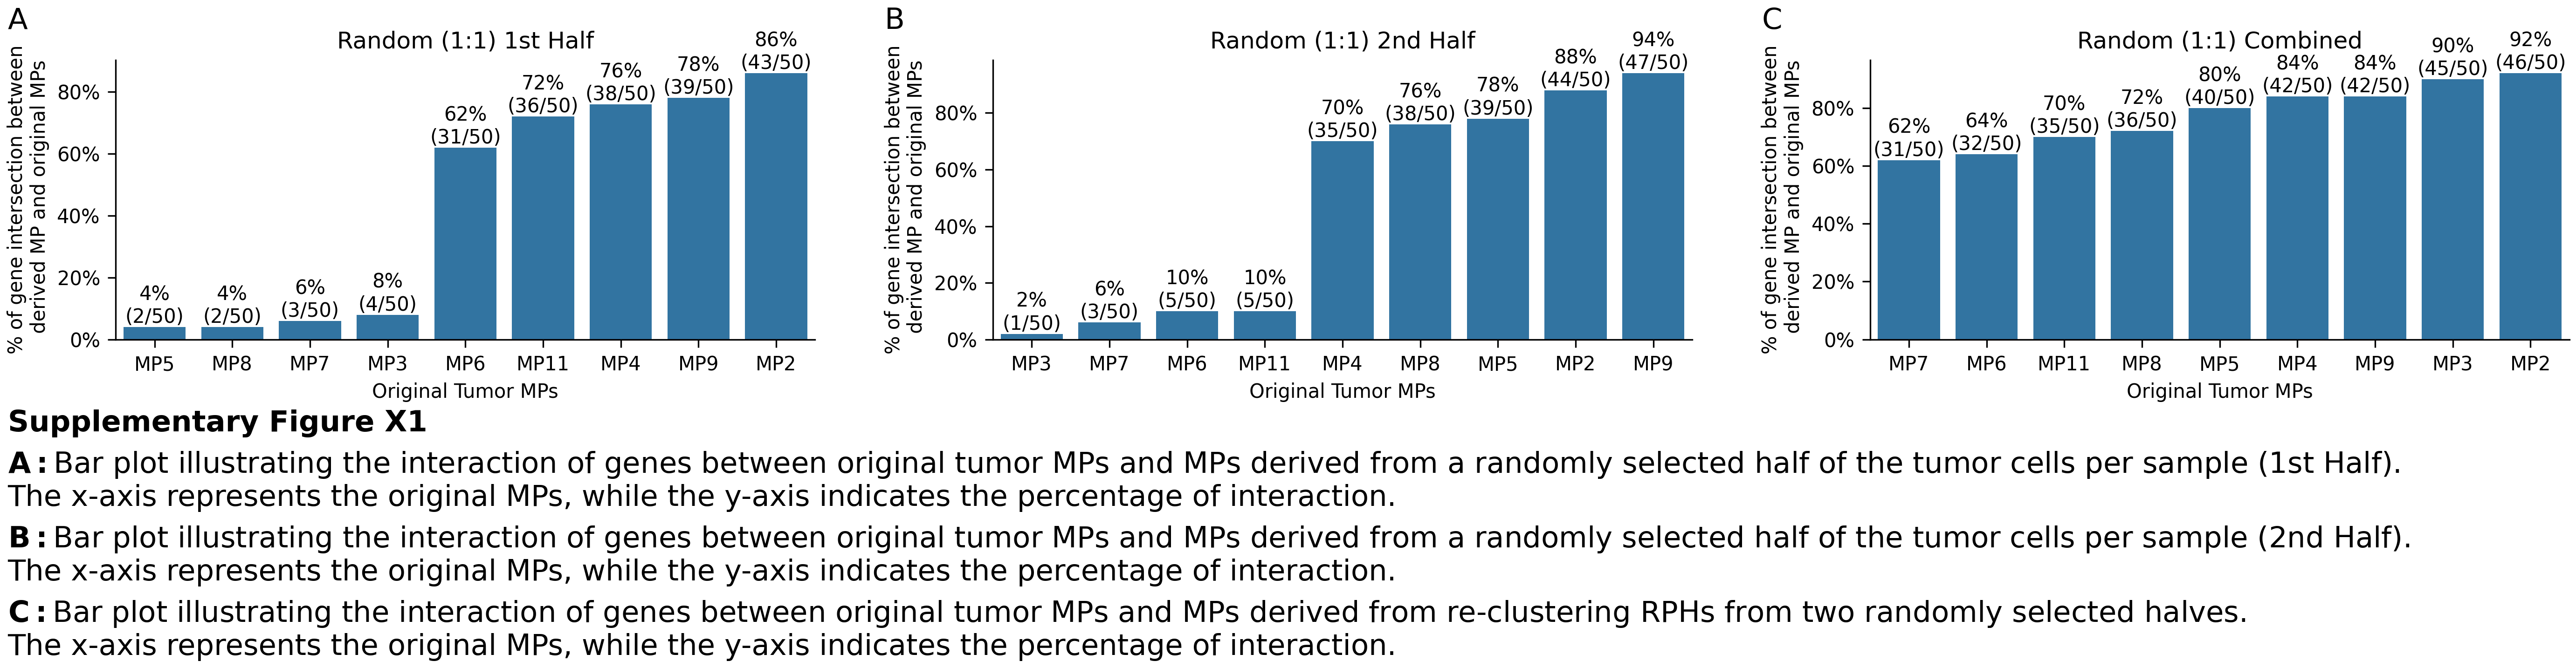

In [7]:
fontsize=15
ax1 = pw.Brick(figsize=(5,2))
ax1.set_index('A',fontsize=fontsize)
summary = sm1.max(axis=1).sort_values()
sns.barplot(data=summary/50,ax=ax1)
ax1.set(title='Random (1:1) 1st Half',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')
for i,overlap_count in enumerate(summary):
    ax1.text(i, overlap_count/50, f'{(overlap_count/50)*100:.0f}%\n({overlap_count:.0f}/50)', ha='center', va='bottom')
ax1.set_yticklabels(['{:.0%}'.format(x) for x in ax1.get_yticks()])

ax2 = pw.Brick(figsize=(5,2))
ax2.set_index('B',fontsize=fontsize)
summary = sm2.max(axis=1).sort_values()
sns.barplot(data=summary/50,ax=ax2)
ax2.set(title='Random (1:1) 2nd Half',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')
for i,overlap_count in enumerate(summary):
    ax2.text(i, overlap_count/50, f'{(overlap_count/50)*100:.0f}%\n({overlap_count:.0f}/50)', ha='center', va='bottom')
ax2.set_yticklabels(['{:.0%}'.format(x) for x in ax2.get_yticks()])


ax3 = pw.Brick(figsize=(5,2))
ax3.set_index('C',fontsize=fontsize)
summary = sm3.max(axis=1).sort_values()
sns.barplot(data=summary/50,ax=ax3)
ax3.set(title='Random (1:1) Combined',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')
for i,overlap_count in enumerate(summary):
    ax3.text(i, overlap_count/50, f'{(overlap_count/50)*100:.0f}%\n({overlap_count:.0f}/50)', ha='center', va='bottom')
        
ax3.set_yticklabels(['{:.0%}'.format(x) for x in ax3.get_yticks()])

fig = ax1|ax2|ax3

fig.set_text(0,-.08,"Supplementary Figure X1 ", fontsize=fontsize,fontweight='bold')
fig.set_text(0,-.28,r'$\bf A:$'+'Bar plot illustrating the interaction of genes between original tumor MPs and MPs derived from a randomly selected half of the tumor cells per sample (1st Half).\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
            fontsize=fontsize)
fig.set_text(0,-.48,r'$\bf B:$'+'Bar plot illustrating the interaction of genes between original tumor MPs and MPs derived from a randomly selected half of the tumor cells per sample (2nd Half).\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
             fontsize=fontsize)
fig.set_text(0,-.68,r'$\bf C:$'+'Bar plot illustrating the interaction of genes between original tumor MPs and MPs derived from re-clustering RPHs from two randomly selected halves.\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
            fontsize=fontsize)

fig


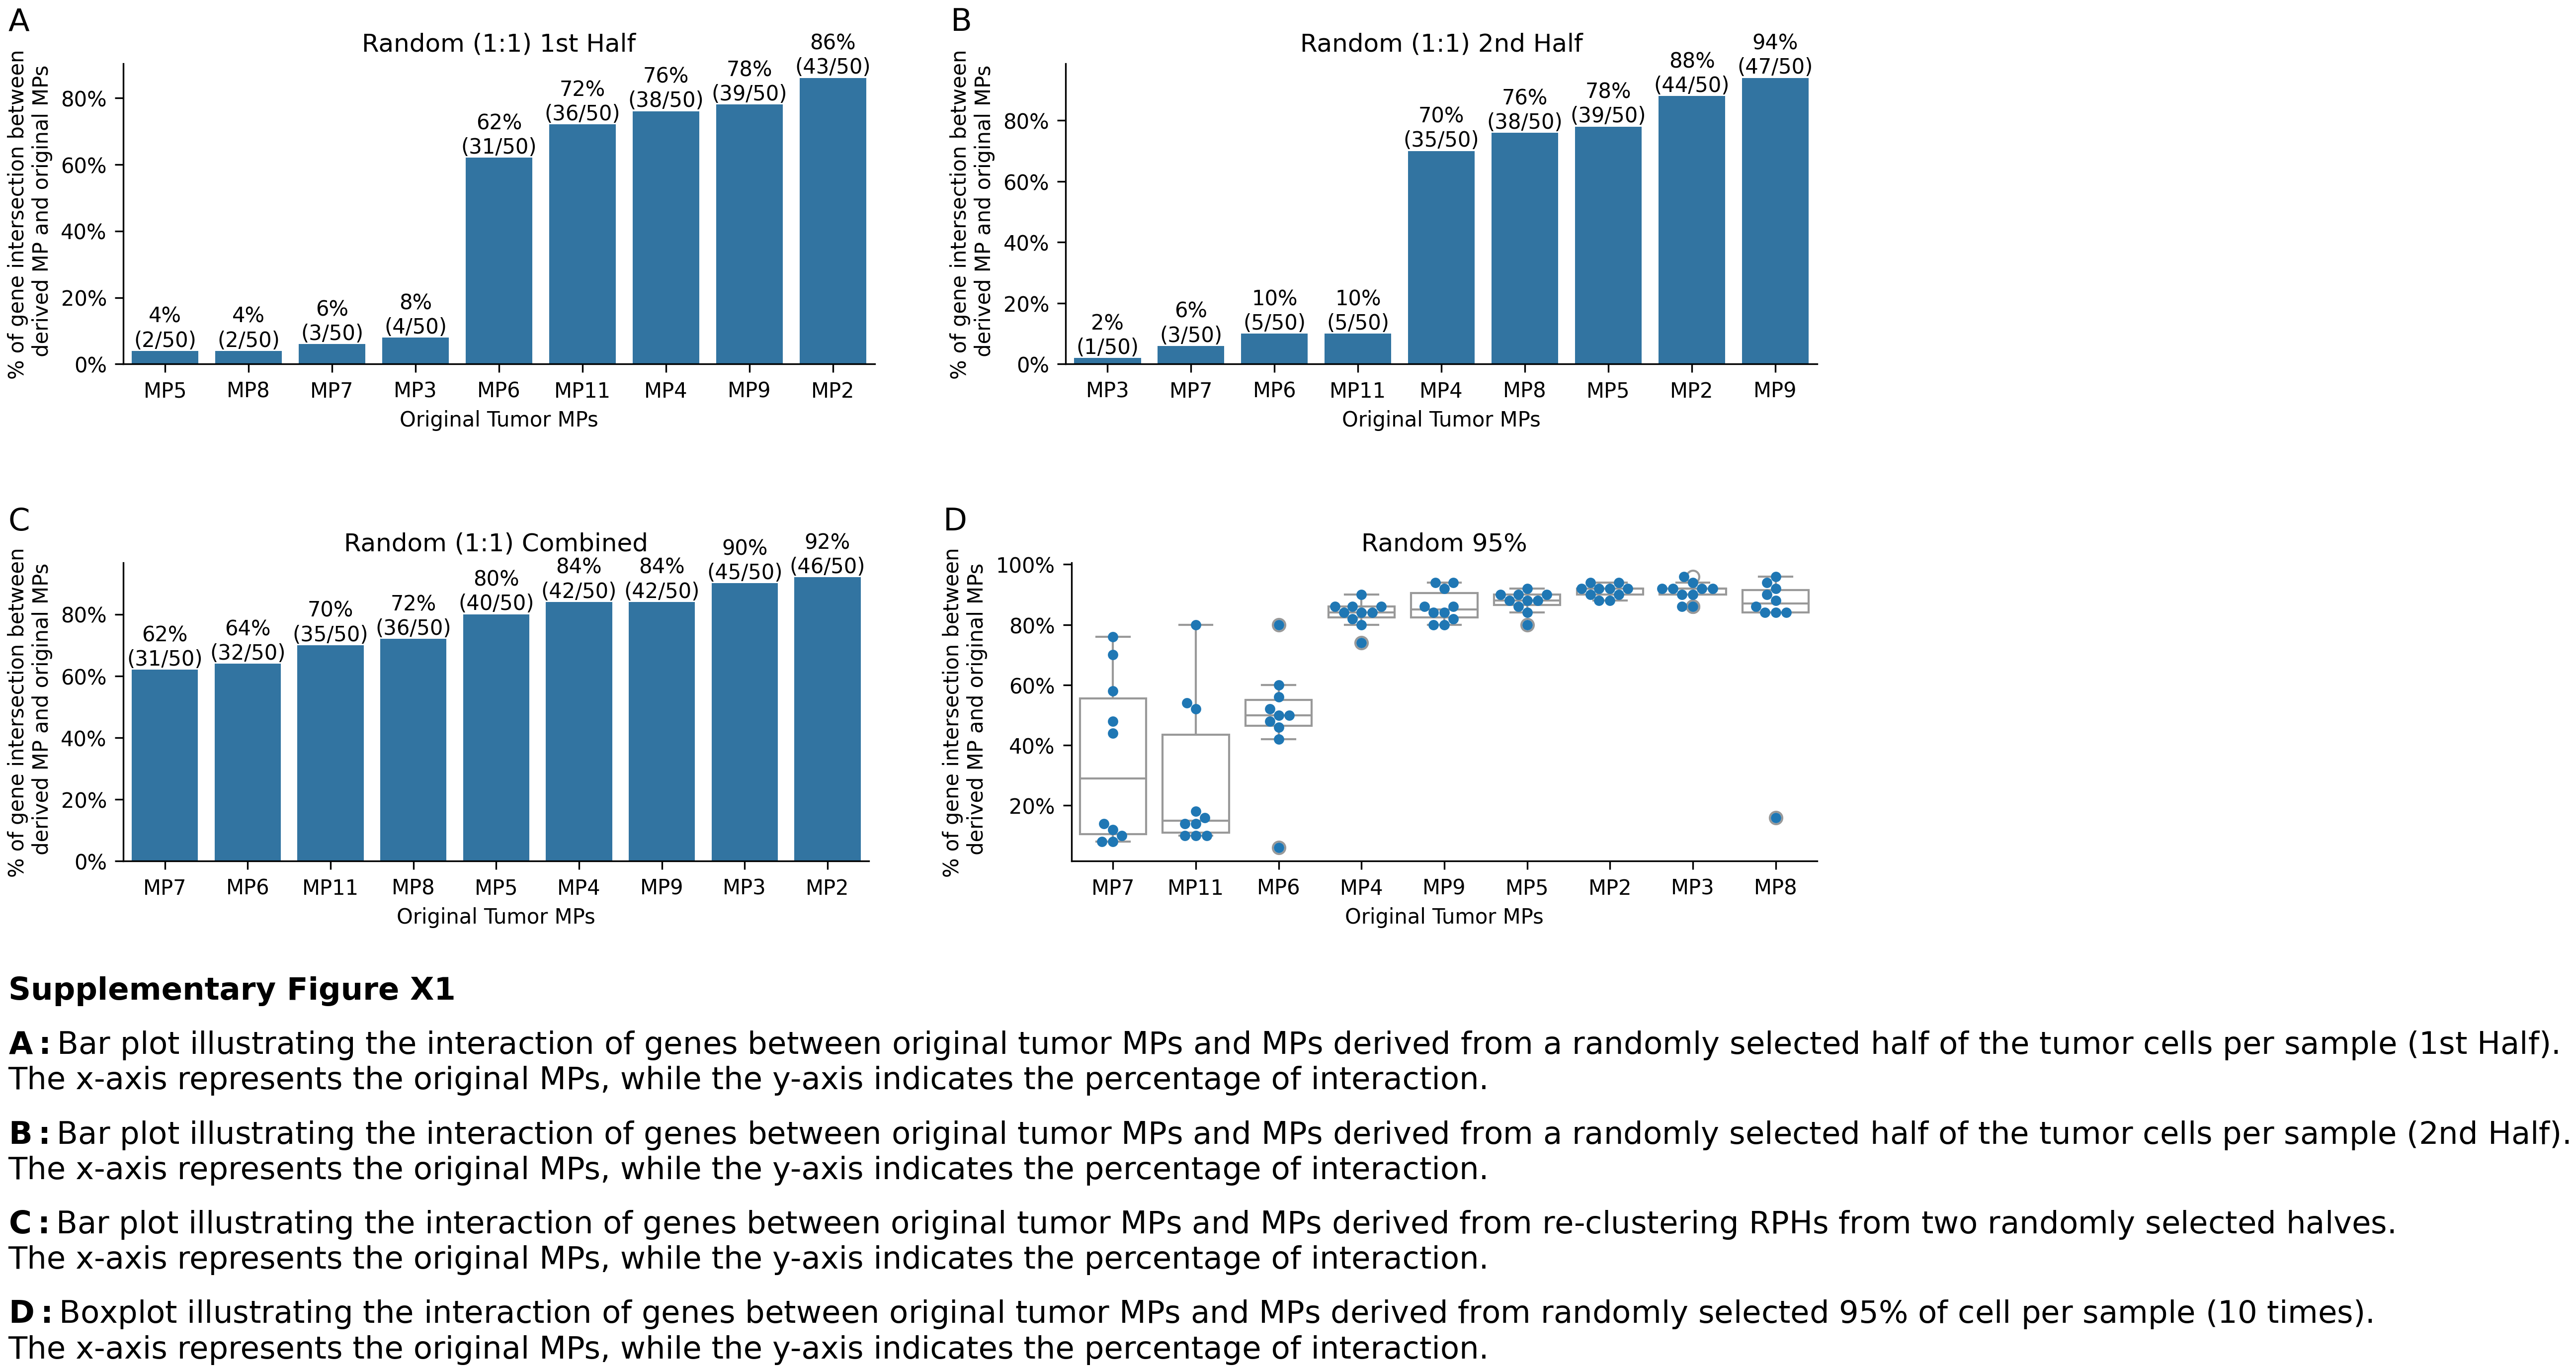

In [5]:
fontsize=15
ax1 = pw.Brick(figsize=(5,2))
ax1.set_index('A',fontsize=fontsize)
summary = sm1.max(axis=1).sort_values()
sns.barplot(data=summary/50,ax=ax1)
ax1.set(title='Random (1:1) 1st Half',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')
for i,overlap_count in enumerate(summary):
    ax1.text(i, overlap_count/50, f'{(overlap_count/50)*100:.0f}%\n({overlap_count:.0f}/50)', ha='center', va='bottom')
ax1.set_yticklabels(['{:.0%}'.format(x) for x in ax1.get_yticks()])

ax2 = pw.Brick(figsize=(5,2))
ax2.set_index('B',fontsize=fontsize)
summary = sm2.max(axis=1).sort_values()
sns.barplot(data=summary/50,ax=ax2)
ax2.set(title='Random (1:1) 2nd Half',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')
for i,overlap_count in enumerate(summary):
    ax2.text(i, overlap_count/50, f'{(overlap_count/50)*100:.0f}%\n({overlap_count:.0f}/50)', ha='center', va='bottom')
ax2.set_yticklabels(['{:.0%}'.format(x) for x in ax2.get_yticks()])


ax3 = pw.Brick(figsize=(5,2))
ax3.set_index('C',fontsize=fontsize)
summary = sm3.max(axis=1).sort_values()
sns.barplot(data=summary/50,ax=ax3)
ax3.set(title='Random (1:1) Combined',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')
for i,overlap_count in enumerate(summary):
    ax3.text(i, overlap_count/50, f'{(overlap_count/50)*100:.0f}%\n({overlap_count:.0f}/50)', ha='center', va='bottom')
        
ax3.set_yticklabels(['{:.0%}'.format(x) for x in ax3.get_yticks()])

ax4 = pw.Brick(figsize=(5,2))
ax4.set_index('D',fontsize=fontsize)
sns.swarmplot(data=random_result.unstack().rename('percent').reset_index(),
              x='MPs',y='percent',ax=ax4)
sns.boxplot(data=random_result.unstack().rename('percent').reset_index(),
              x='MPs',y='percent',ax=ax4,color='white')
ax4.set_yticklabels(['{:.0%}'.format(x) for x in ax4.get_yticks()])
ax4.set(title='Random 95%',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')

fig = (ax1|ax2)/(ax3|ax4)

fig.set_text(0,-.08,"Supplementary Figure X1 ", fontsize=fontsize,fontweight='bold')
fig.set_text(0,-.18,r'$\bf A:$'+'Bar plot illustrating the interaction of genes between original tumor MPs and MPs derived from a randomly selected half of the tumor cells per sample (1st Half).\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
            fontsize=fontsize)
fig.set_text(0,-.28,r'$\bf B:$'+'Bar plot illustrating the interaction of genes between original tumor MPs and MPs derived from a randomly selected half of the tumor cells per sample (2nd Half).\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
             fontsize=fontsize)
fig.set_text(0,-.38,r'$\bf C:$'+'Bar plot illustrating the interaction of genes between original tumor MPs and MPs derived from re-clustering RPHs from two randomly selected halves.\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
            fontsize=fontsize)

fig.set_text(0,-.48,r'$\bf D:$'+'Boxplot illustrating the interaction of genes between original tumor MPs and MPs derived from randomly selected 95% of cell per sample (10 times).\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
            fontsize=fontsize)

fig


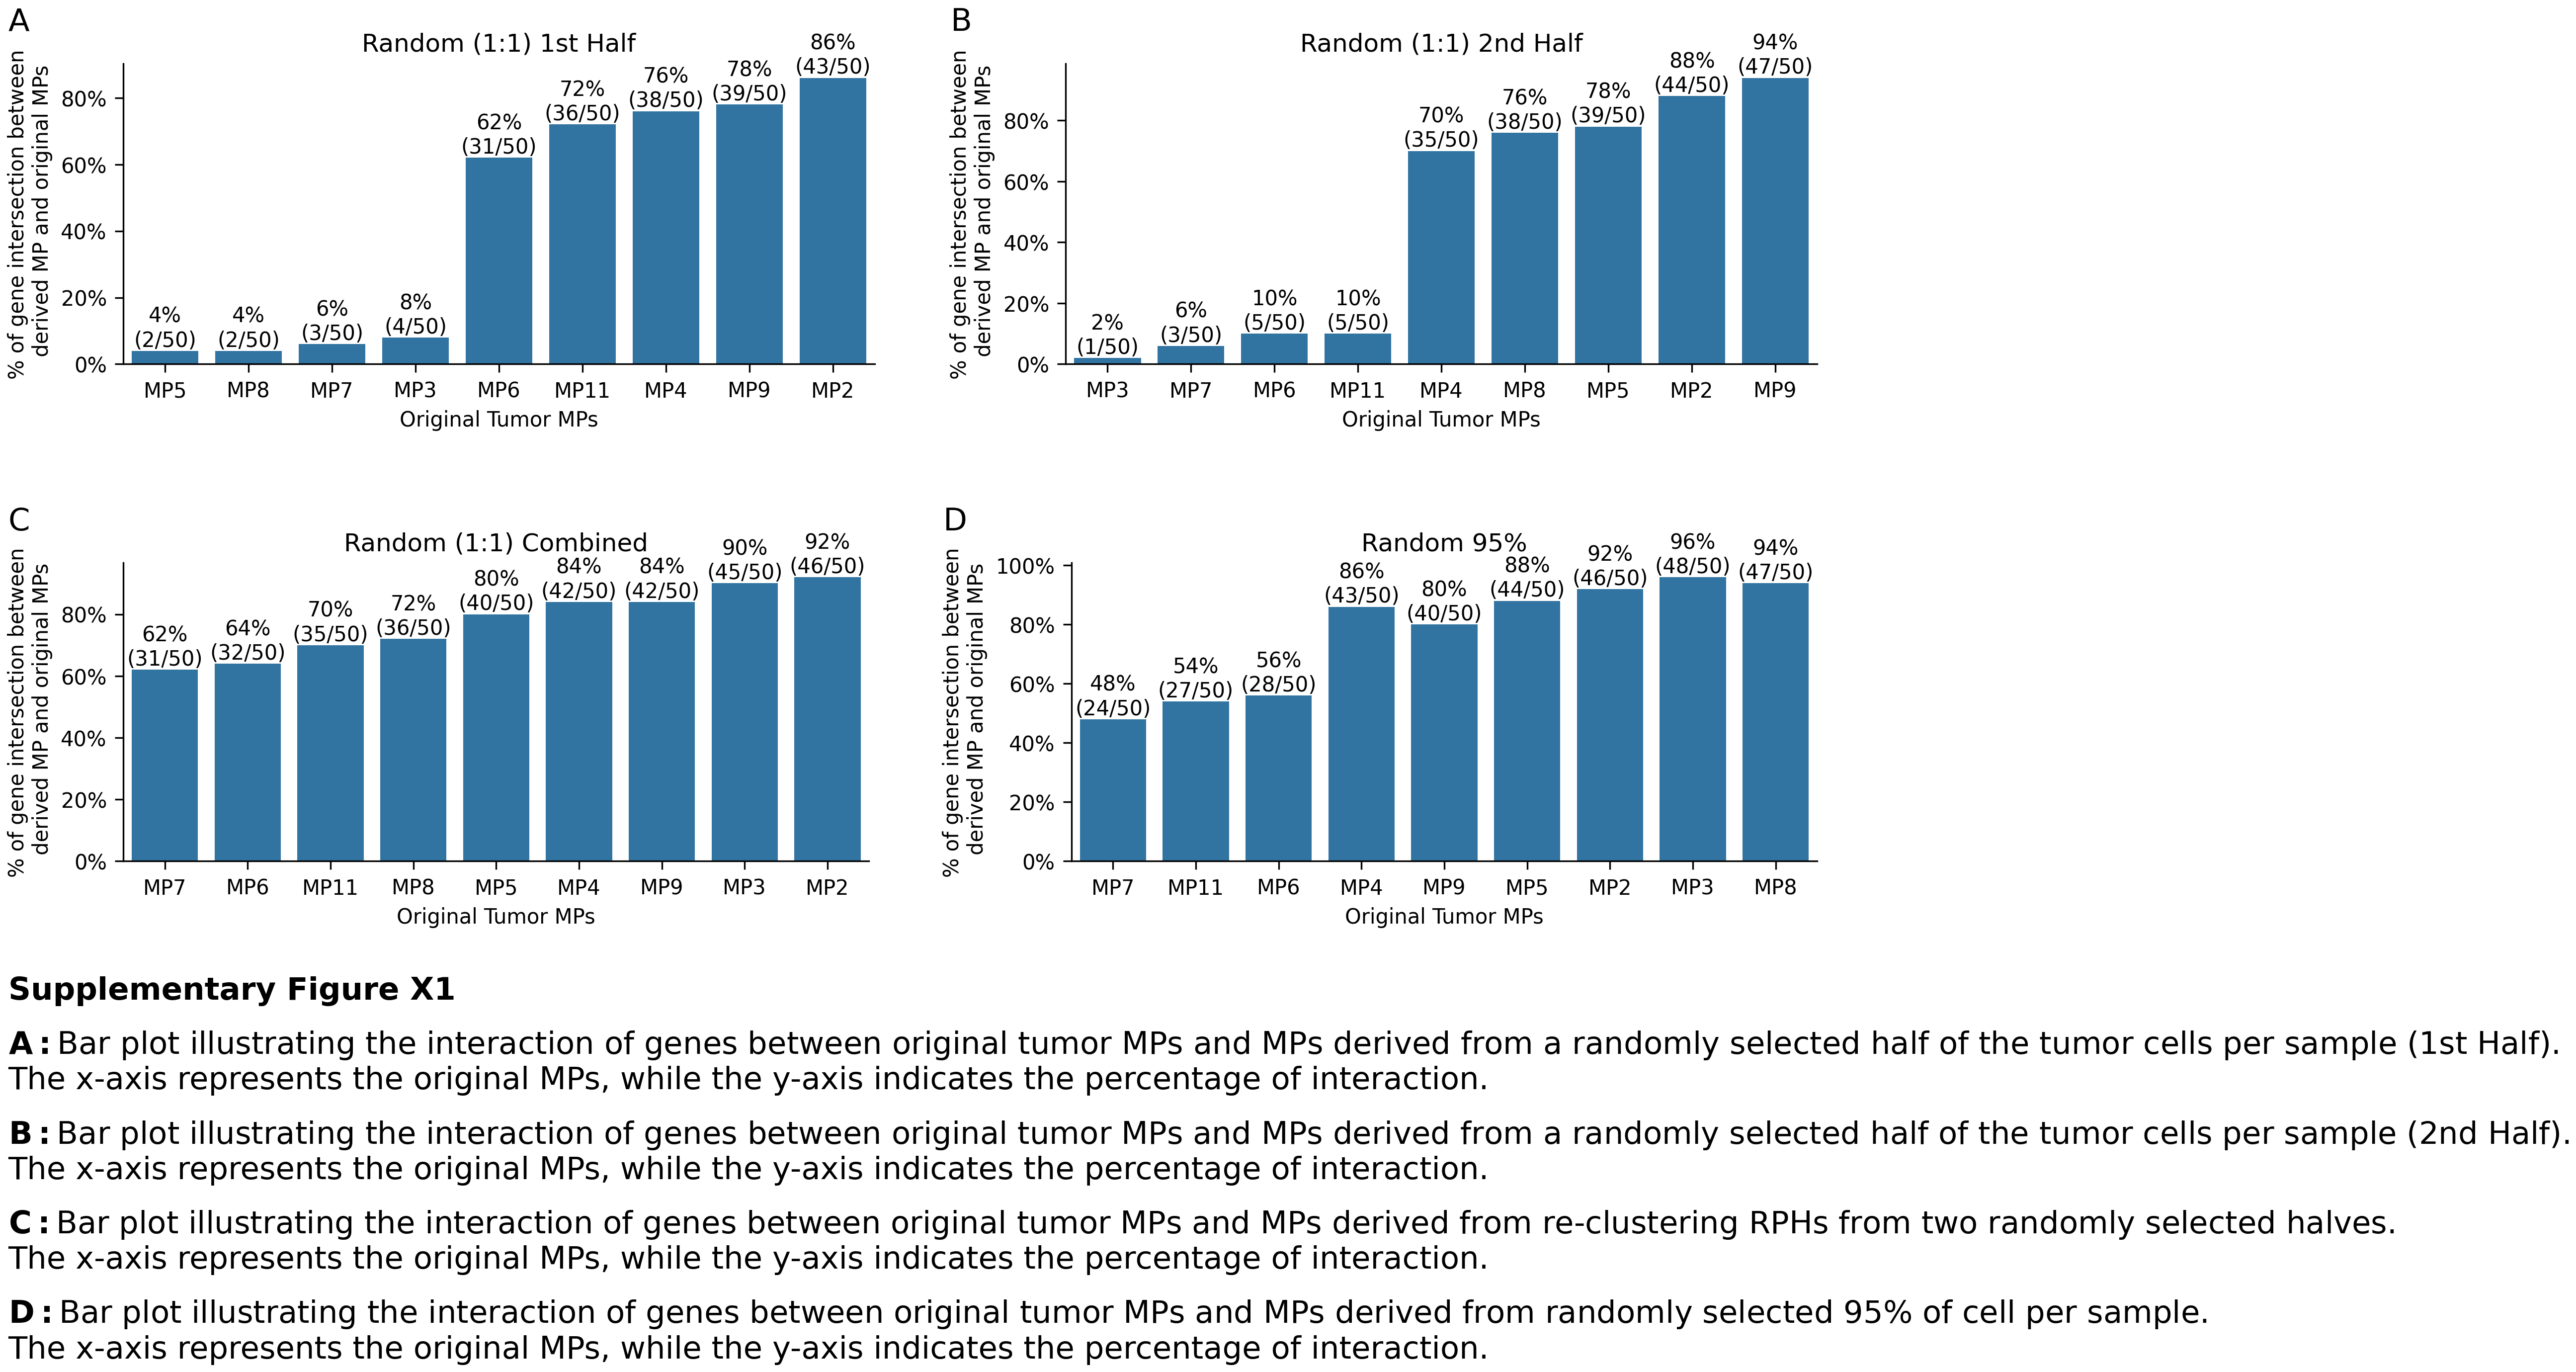

In [21]:
fontsize=15
ax1 = pw.Brick(figsize=(5,2))
ax1.set_index('A',fontsize=fontsize)
summary = sm1.max(axis=1).sort_values()
sns.barplot(data=summary/50,ax=ax1)
ax1.set(title='Random (1:1) 1st Half',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')
for i,overlap_count in enumerate(summary):
    ax1.text(i, overlap_count/50, f'{(overlap_count/50)*100:.0f}%\n({overlap_count:.0f}/50)', ha='center', va='bottom')
ax1.set_yticklabels(['{:.0%}'.format(x) for x in ax1.get_yticks()])

ax2 = pw.Brick(figsize=(5,2))
ax2.set_index('B',fontsize=fontsize)
summary = sm2.max(axis=1).sort_values()
sns.barplot(data=summary/50,ax=ax2)
ax2.set(title='Random (1:1) 2nd Half',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')
for i,overlap_count in enumerate(summary):
    ax2.text(i, overlap_count/50, f'{(overlap_count/50)*100:.0f}%\n({overlap_count:.0f}/50)', ha='center', va='bottom')
ax2.set_yticklabels(['{:.0%}'.format(x) for x in ax2.get_yticks()])


ax3 = pw.Brick(figsize=(5,2))
ax3.set_index('C',fontsize=fontsize)
summary = sm3.max(axis=1).sort_values()
sns.barplot(data=summary/50,ax=ax3)
ax3.set(title='Random (1:1) Combined',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')
for i,overlap_count in enumerate(summary):
    ax3.text(i, overlap_count/50, f'{(overlap_count/50)*100:.0f}%\n({overlap_count:.0f}/50)', ha='center', va='bottom')
        
ax3.set_yticklabels(['{:.0%}'.format(x) for x in ax3.get_yticks()])

ax4 = pw.Brick(figsize=(5,2))
ax4.set_index('D',fontsize=fontsize)
sns.barplot(data=random_result.loc['TumorRandom90_9',:].T,ax=ax4)
for i,percent in enumerate(random_result.loc['TumorRandom90_9',:].T):
    ax4.text(i, percent, f'{percent*100:.0f}%\n({percent*50:.0f}/50)', ha='center', va='bottom')
    
ax4.set_yticklabels(['{:.0%}'.format(x) for x in ax4.get_yticks()])
ax4.set(title='Random 95%',xlabel='Original Tumor MPs',ylabel='% of gene intersection between\n derived MP and original MPs')

fig = (ax1|ax2)/(ax3|ax4)

fig.set_text(0,-.08,"Supplementary Figure X1 ", fontsize=fontsize,fontweight='bold')
fig.set_text(0,-.18,r'$\bf A:$'+'Bar plot illustrating the interaction of genes between original tumor MPs and MPs derived from a randomly selected half of the tumor cells per sample (1st Half).\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
            fontsize=fontsize)
fig.set_text(0,-.28,r'$\bf B:$'+'Bar plot illustrating the interaction of genes between original tumor MPs and MPs derived from a randomly selected half of the tumor cells per sample (2nd Half).\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
             fontsize=fontsize)
fig.set_text(0,-.38,r'$\bf C:$'+'Bar plot illustrating the interaction of genes between original tumor MPs and MPs derived from re-clustering RPHs from two randomly selected halves.\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
            fontsize=fontsize)

fig.set_text(0,-.48,r'$\bf D:$'+'Bar plot illustrating the interaction of genes between original tumor MPs and MPs derived from randomly selected 95% of cell per sample.\nThe x-axis represents the original MPs, while the y-axis indicates the percentage of interaction.',
            fontsize=fontsize)

fig